# library

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
os.chdir(r"D:\nishkama karma\nidhidyasana\Paytm-FinTech-Analytics-AI-Platform\payments_fraud_analytics")

In [49]:
merchant_df = pd.read_csv("merchants.csv")

In [8]:
ledger_df = pd.read_csv('ledger.csv')
gateway_df = pd.read_csv('gateway_export.csv') 
merged_df = pd.merge(ledger_df, gateway_df, on='transaction_id', suffixes=('_ledger', '_gateway')) 
merged_df.head() 

,transaction_id,user_id_ledger,merchant_id_ledger,transaction_time_ledger,amount_inr_ledger,payment_method_ledger,status_ledger,risk_score_ledger,user_id_gateway,merchant_id_gateway,transaction_time_gateway,amount_inr_gateway,payment_method_gateway,status_gateway,risk_score_gateway
0,TXN100001,287,27,04-01-2026 11:49,49,UPI,captured,79,287,27,2026-01-04 11:49:00,49,UPI,captured,79
1,TXN100002,122,11,24-01-2026 04:59,1499,Wallet,captured,22,122,11,2026-01-24 04:59:00,1499,Wallet,captured,22
2,TXN100003,92,22,29-01-2026 13:01,49,Netbanking,captured,100,92,22,2026-01-29 13:01:00,49,Netbanking,captured,100
3,TXN100004,343,16,30-01-2026 13:51,99,UPI,captured,34,343,16,2026-01-30 13:51:00,99,UPI,captured,34
4,TXN100006,236,23,08-01-2026 06:52,99,Wallet,captured,39,236,23,2026-01-08 06:52:00,99,Wallet,captured,39


# Headline layer

### (total GMV in INR, overall success rate, reconciliation match rate, chargeback ratio)

1. Total GMV in INR:

This is the total monetary value of all transactions in your ledger.


In [30]:
total_gmv = ledger_df['amount_inr'].sum() 
print(f"Total sum of amount_inr in ledger_df: {total_gmv}")

Total sum of amount_inr in ledger_df: 382603


2. Chargeback Ratio:

The prompt explicitly defines this as: (count of transactions with status == "chargeback") / (count of all transactions).

In [28]:
# Question: How would you get the length of the filtered dataframe where the status is "chargeback", 
# and divide it by the total number of rows in ledger_df? 
chargeback_count = len(ledger_df[ledger_df['status'] == 'chargeback']) 
chargeback_ratio = chargeback_count / len(ledger_df)
print(f"Chargeback ratio: {chargeback_ratio}")

Chargeback ratio: 0.051188299817184646


3. Overall Success Rate:

This uses the exact same logic as the Chargeback Ratio, but for successful transactions.

Question: Assuming the status is called "success" or "Success", how would you adapt your chargeback ratio logic to find the success percentage?

In [27]:
success_rate = len(ledger_df[ledger_df['status']=='captured']) / len(ledger_df)
print(f"Success rate: {success_rate}") 

Success rate: 0.8555758683729433


4. reconciliation match rate


In [24]:
match_rate = len(merged_df[(merged_df["amount_inr_ledger"] == merged_df["amount_inr_gateway"]) & 
                           (merged_df["status_ledger"] == merged_df["status_gateway"])]) / len(merged_df)
match_rates = match_rate / len(ledger_df)
print(f"Match rate: {match_rates}") 

Match rate: 0.0017402615665869777


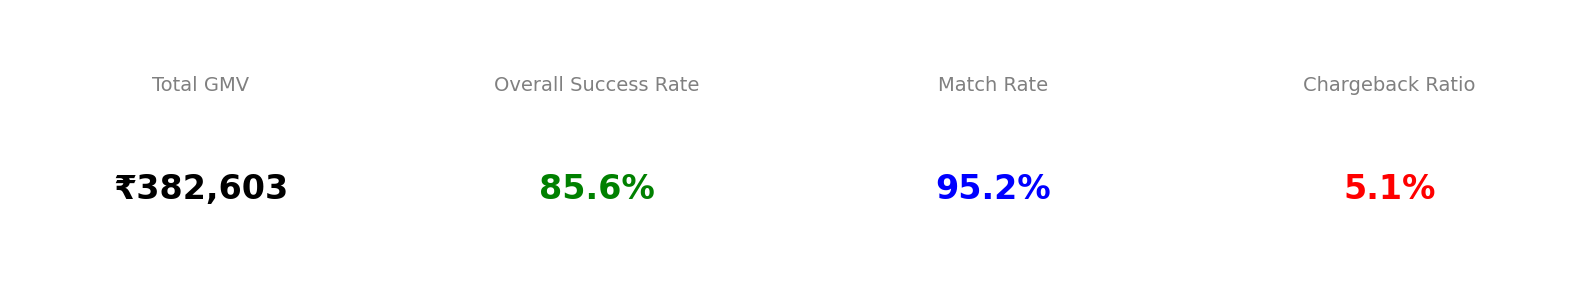

<Figure size 640x480 with 0 Axes>

In [57]:
import matplotlib.pyplot as plt

# Create a figure with 1 row, 4 columns, and make it wide (16x3 inches)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 3))

# 1. Total GMV (Leftmost canvas: axes[0])
axes[0].axis('off') # Hides the graph lines
axes[0].text(0.5, 0.7, 'Total GMV', fontsize=14, ha='center', color='gray')
axes[0].text(0.5, 0.3, f"₹{total_gmv:,.0f}", fontsize=24, weight='bold', ha='center')

# 2. Overall Success Rate (axes[1])
axes[1].axis('off')
axes[1].text(0.5, 0.7, 'Overall Success Rate', fontsize=14, ha='center', color='gray')
axes[1].text(0.5, 0.3, f"{success_rate * 100:.1f}%", fontsize=24, weight='bold', ha='center', color='green')

# 3. Reconciliation Match Rate (axes[2])
axes[2].axis('off')
axes[2].text(0.5, 0.7, 'Match Rate', fontsize=14, ha='center', color='gray')
axes[2].text(0.5, 0.3, f"{match_rate * 100:.1f}%", fontsize=24, weight='bold', ha='center', color='blue')

# 4. Chargeback Ratio (Rightmost canvas: axes[3])
axes[3].axis('off')
axes[3].text(0.5, 0.7, 'Chargeback Ratio', fontsize=14, ha='center', color='gray')
axes[3].text(0.5, 0.3, f"{chargeback_ratio * 100:.1f}%", fontsize=24, weight='bold', ha='center', color='red')

# Display the clean dashboard header
plt.tight_layout()
plt.show()
plt.savefig('dashboard.png', dpi=300, bbox_inches='tight')

# Trends layer

a time-series chart of daily GMV and daily chargeback count over the 30-day window.

C:\Users\Avinash\AppData\Local\Temp\ipykernel_4860\3174037074.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ledger_df['date'] = pd.to_datetime(ledger_df['transaction_time']).dt.normalize()


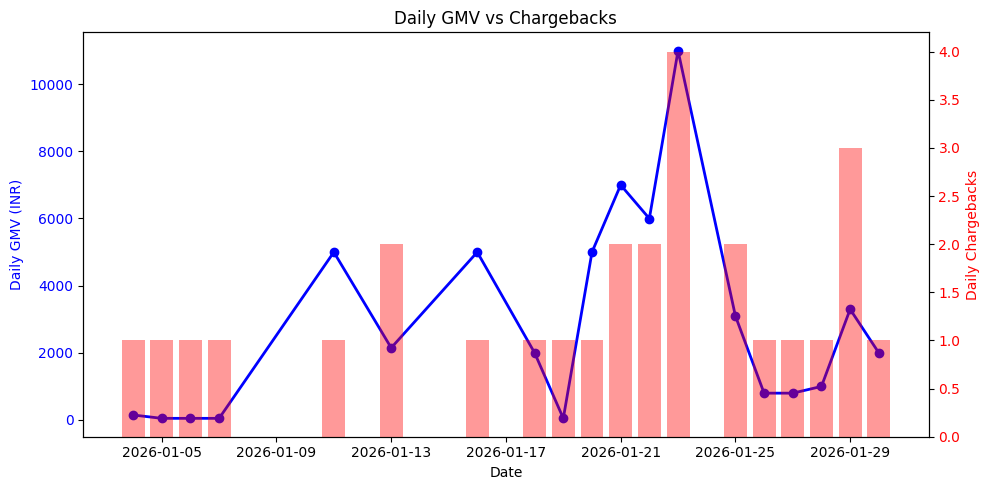

<Figure size 640x480 with 0 Axes>

In [59]:
ledger_df['date'] = pd.to_datetime(ledger_df['transaction_time']).dt.normalize()

chargebacks_df = ledger_df[ledger_df['status'].str.lower() == 'chargeback'].copy()


latest_date = ledger_df['date'].max()

start_date = latest_date - pd.Timedelta(days=30)

window_df = ledger_df[ledger_df['date'] >= start_date]

daily_gmv = window_df.groupby('date')['amount_inr'].sum()

# Filter chargebacks specifically from the 30-day window
chargebacks_df = window_df[window_df['status'].str.lower() == 'chargeback']
daily_chargebacks = chargebacks_df.groupby('date').size()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily_gmv.index, daily_gmv.values, color='blue', marker='o', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily GMV (INR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.bar(daily_chargebacks.index, daily_chargebacks.values, color='red', alpha=0.4, width=0.8)
ax2.set_ylabel('Daily Chargebacks', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Daily GMV vs Chargebacks')
plt.tight_layout()
plt.show()
plt.savefig('daily_gmv_chargebacks.png', dpi=300, bbox_inches='tight')

# Breakdown layer

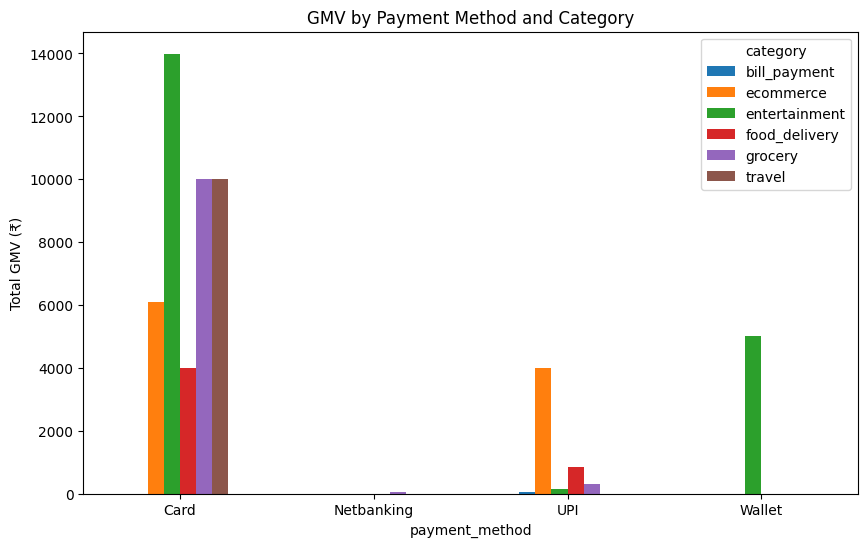

<Figure size 640x480 with 0 Axes>

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Step A: Load the secondary table and merge it with the main ledger
# This correctly brings the 'category' column into your dataset
merged_sales = pd.merge(ledger_df, merchant_df, on='merchant_id', how='left')

# Step B: Group by payment_method AND category, then sum the GMV (amount_inr)
breakdown_data = merged_sales.groupby(['payment_method', 'category'])['amount_inr'].sum()

# Step C: Plot as a grouped bar chart
breakdown_data.unstack().plot(kind='bar', figsize=(10, 6))

# Update the labels to match your FinTech data
plt.title('GMV by Payment Method and Category')
plt.ylabel('Total GMV (₹)')
plt.xticks(rotation=0) # Keeps the payment method names horizontal and readable
plt.show()
plt.savefig('gmv_by_payment_method_and_category.png', dpi=300, bbox_inches='tight')

# Details layer

Details layer: a table, rendered as a saved image (not a live/printed DataFrame), of the top 10 merchants by transaction count, with conditional highlighting (e.g., a flag column) for any merchant whose chargeback_ratio exceeds 1%, using the same count-based definition as above but scoped to that one merchant: chargeback_ratio (per-merchant) = (count of that merchant's transactions with status == "chargeback") / (count of all of that merchant's transactions).

In [52]:
# 1. Count ALL transactions per merchant
total_txns = ledger_df.groupby('merchant_id').size().reset_index(name='total_count')

# 2. Count ONLY chargebacks per merchant
chargebacks_only = ledger_df[ledger_df['status'] == 'chargeback']
cb_counts = chargebacks_only.groupby('merchant_id').size().reset_index(name='cb_count')

# 3. Combine the two lists and fill missing values with 0 (for merchants with 0 chargebacks)
merchant_stats = pd.merge(total_txns, cb_counts, on='merchant_id', how='left').fillna(0)

# 4. Calculate the per-merchant ratio and flag those over 1% (0.01)
merchant_stats['chargeback_ratio'] = merchant_stats['cb_count'] / merchant_stats['total_count']
merchant_stats['high_cb_flag'] = merchant_stats['chargeback_ratio'] > 0.01

# 5. Sort by total transactions (busiest first) and grab the top 10
top_10_merchants = merchant_stats.sort_values(by='total_count', ascending=False).head(10)

# Optional: Format the ratio as a percentage string so it looks nice in the final image
top_10_merchants['chargeback_ratio'] = (top_10_merchants['chargeback_ratio'] * 100).map("{:.2f}%".format)

In [53]:
top_10_merchants

,merchant_id,total_count,cb_count,chargeback_ratio,high_cb_flag
11,27,3,3,100.00%,True
18,39,3,3,100.00%,True
13,29,3,3,100.00%,True
19,40,2,2,100.00%,True
4,10,2,2,100.00%,True
17,37,1,1,100.00%,True
16,36,1,1,100.00%,True
15,32,1,1,100.00%,True
14,31,1,1,100.00%,True
12,28,1,1,100.00%,True
